# ECGR 5105 Assignment 2: Housing Price Prediction using Linear Regression with Gradient Descent

**Name:** Yang Xu  
**Student ID:** 801443244  
**Homework:** 2  

**GitHub Repository**: https://github.com/xuy50/ecgr5105/tree/main/Assignment_2

## Introduction

In this notebook, will predict the housing price using a linear regression model with a custom implementation of the gradient descent algorithm. Use the Housing dataset and explore different feature sets and preprocessing techniques. The homework is divided into three major problems:

- **Problem 1:** Baseline gradient descent training using two different sets of input features.
- **Problem 2:** The same training experiments as in Problem 1 but with input normalization and standardization.
- **Problem 3:** Adding an L2 regularization (penalty) to the loss function and modifying the gradient descent update accordingly.

### Import Libraries

Import the necessary Python libraries for data manipulation, visualization, and model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Cost Function and Gradient Descent Function

The function `compute_cost` calculates the Mean Squared Error (MSE) between the predictions and true values.  
The function `gradient_descent_with_validation` performs gradient descent updates on the training set and computes the cost for both the training and validation sets at each iteration.  
An optional L2 regularization (penalty) term is included in both functions.

The `plot_loss_curves` function is used to plot training and validation loss curves over the iterations, and `add_intercept` is a helper function to add an intercept term to the feature matrix.

In [2]:
# Cost Function and Gradient Descent (with optional L2 regularization)
def compute_cost(X, y, theta, penalty=0):
    m = len(y)
    predictions = X.dot(theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    if penalty != 0:
        cost += (penalty / (2 * m)) * np.sum(theta[1:] ** 2)
    return cost

def gradient_descent_with_validation(X_train, y_train, X_val, y_val, theta, alpha, iterations, penalty=0):
    m_train = len(y_train)
    train_cost_history = []
    val_cost_history = []
    for i in range(iterations):
        predictions_train = X_train.dot(theta)
        errors_train = predictions_train - y_train
        gradient = (1 / m_train) * X_train.T.dot(errors_train)
        reg_term = (penalty / m_train) * np.concatenate(([0], theta[1:]))
        theta = theta - alpha * (gradient + reg_term)
        train_cost_history.append(compute_cost(X_train, y_train, theta, penalty))
        val_cost_history.append(compute_cost(X_val, y_val, theta, penalty))
    return theta, train_cost_history, val_cost_history

# Plotting function for loss curves
def plot_loss_curves(train_losses, val_losses, title):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Iteration')
    plt.ylabel('MSE Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Utility: add intercept term to feature matrix
def add_intercept(X):
    intercept = np.ones((X.shape[0], 1))
    return np.hstack((intercept, X))

### Data Loading and Preprocessing

Load the US Housing dataset from `Housing.csv` and perform preprocessing.  
- Categorical columns (yes/no) are converted to numeric values (1 for 'yes', 0 for 'no').  
- Continuous features including the target variable 'price' are normalized using `StandardScaler`.  
This normalized dataset will be used for the experiments.

In [3]:
# Load the dataset (ensure that Housing.csv is in the working directory)
housing_df = pd.read_csv('Housing.csv')

# Display the dataset length and shape
print(len(housing_df))
print(housing_df.shape)

# Display the first few rows to verify
print(housing_df.head())

545
(545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


### Normalization & Preprocessing Initialization

This block converts categorical yes/no columns into numeric values and maps the furnishingstatus.
It also scales the target variable 'price' and normalizes the 'area' feature for later use.

In [4]:
# Convert yes/no columns to numeric (1 for 'yes', 0 for 'no')
yesno_cols = ["mainroad", "guestroom", "basement", "hotwaterheating", "airconditioning", "prefarea"]
for c in yesno_cols:
    housing_df[c] = housing_df[c].map({'yes': 1, 'no': 0})

# Map furnishingstatus: furnished / semi-furnished / unfurnished
status_map = {'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0}
housing_df['furnishingstatus'] = housing_df['furnishingstatus'].map(status_map)

# Scale the target variable 'price' using StandardScaler (or you can divide by 1e6 for baseline)
price_scaler = StandardScaler()
housing_df['price'] = price_scaler.fit_transform(housing_df[['price']])

# Normalize the 'area' feature using StandardScaler (this is just for later experiments)
area_scaler = StandardScaler()
housing_df['area'] = area_scaler.fit_transform(housing_df[['area']])

print("After conversion:\n", housing_df.head())

After conversion:
       price      area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  4.566365  1.046726         4          2        3         1          0   
1  4.004484  1.757010         4          4        4         1          0   
2  4.004484  2.218232         3          2        2         1          0   
3  3.985755  1.083624         4          2        2         1          0   
4  3.554979  1.046726         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 2  
1                 2  
2                 1  
3                 2  
4    

## Problem 1: Baseline Linear Regression (Without Scaling)

### Problem 1a:
Predict housing price using the following input variables:
- **Features:** area, bedrooms, bathrooms, stories, parking

Split the dataset into 80% training and 20% validation sets, initialize the parameters to zero, and use gradient descent to learn the model. Explore learning rates between 0.1 and 0.01 and select an appropriate number of iterations. The training and validation losses (MSE) will be plotted in one graph.

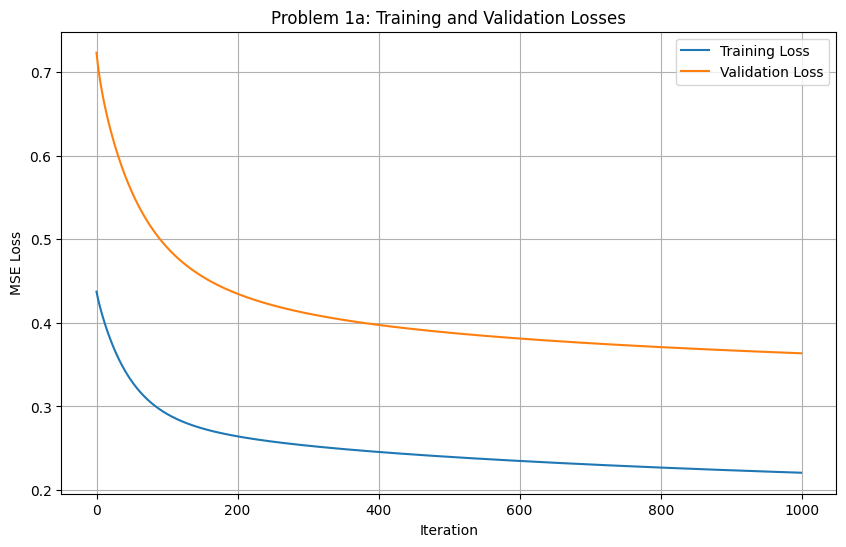

Problem 1a - Final theta: [-0.6676048   0.41227234 -0.13480065  0.39719397  0.26104236  0.16582258]
Problem 1a - Final Training Loss: 0.22062905584423204
Problem 1a - Final Validation Loss: 0.36355315040037284


In [5]:
# Select features and target for Problem 1a
features_1a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
target = 'price'

X_1a = housing_df[features_1a].values  # using normalized data
y = housing_df[target].values

# Split data into training (80%) and validation (20%)
X_train_1a, X_val_1a, y_train_1a, y_val_1a = train_test_split(X_1a, y, test_size=0.20, random_state=42)

# Add intercept term
X_train_1a = add_intercept(X_train_1a)
X_val_1a = add_intercept(X_val_1a)

# Initialize parameters (theta) to zeros
theta_initial_1a = np.zeros(X_train_1a.shape[1])

# Set learning rate and iterations
alpha_1a = 0.01
iterations = 1000

# Run gradient descent for Problem 1a
theta_1a, train_losses_1a, val_losses_1a = gradient_descent_with_validation(
    X_train_1a, y_train_1a, X_val_1a, y_val_1a, theta_initial_1a, alpha_1a, iterations, penalty=0)

# Plot training and validation loss curves
plot_loss_curves(train_losses_1a, val_losses_1a, 'Problem 1a: Training and Validation Losses')

print("Problem 1a - Final theta:", theta_1a)
print("Problem 1a - Final Training Loss:", train_losses_1a[-1])
print("Problem 1a - Final Validation Loss:", val_losses_1a[-1])

### Problem 1a: Learning Rate Comparison

Explore the effect of different learning rates (0.1, 0.05, and 0.01) on the training process for Problem 1a.  
For each learning rate, gradient descent is executed and the corresponding training and validation losses are recorded and plotted for comparison.

LR=0.1: Final Training Loss = 0.1933, Final Validation Loss = 0.3284
LR=0.05: Final Training Loss = 0.1938, Final Validation Loss = 0.3302
LR=0.01: Final Training Loss = 0.2206, Final Validation Loss = 0.3636


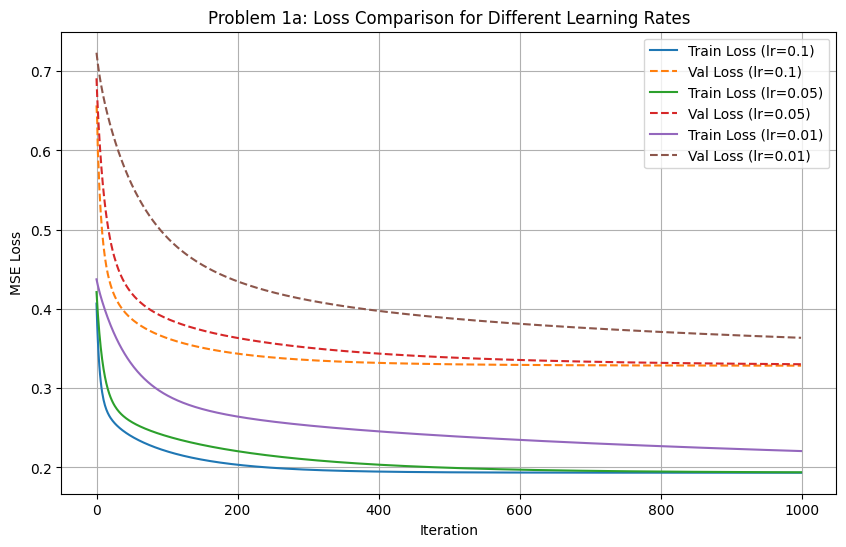

In [6]:
learning_rates_1a = [0.1, 0.05, 0.01]
results_1a = {}

for lr in learning_rates_1a:
    theta, train_losses, val_losses = gradient_descent_with_validation(
        X_train_1a, y_train_1a, X_val_1a, y_val_1a, theta_initial_1a.copy(), lr, iterations, penalty=0)
    results_1a[lr] = {'theta': theta, 'train_losses': train_losses, 'val_losses': val_losses}
    print(f"LR={lr}: Final Training Loss = {train_losses[-1]:.4f}, Final Validation Loss = {val_losses[-1]:.4f}")

plt.figure(figsize=(10,6))
for lr in learning_rates_1a:
    plt.plot(results_1a[lr]['train_losses'], label=f'Train Loss (lr={lr})')
    plt.plot(results_1a[lr]['val_losses'], '--', label=f'Val Loss (lr={lr})')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 1a: Loss Comparison for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

### Problem 1b:
Predict housing price using the following input variables:
- **Features:** area, bedrooms, bathrooms, stories, main road, guestroom, basement, hot water heating, air conditioning, parking, prefarea

Repeat the same process as in Problem 1a with the expanded feature set.

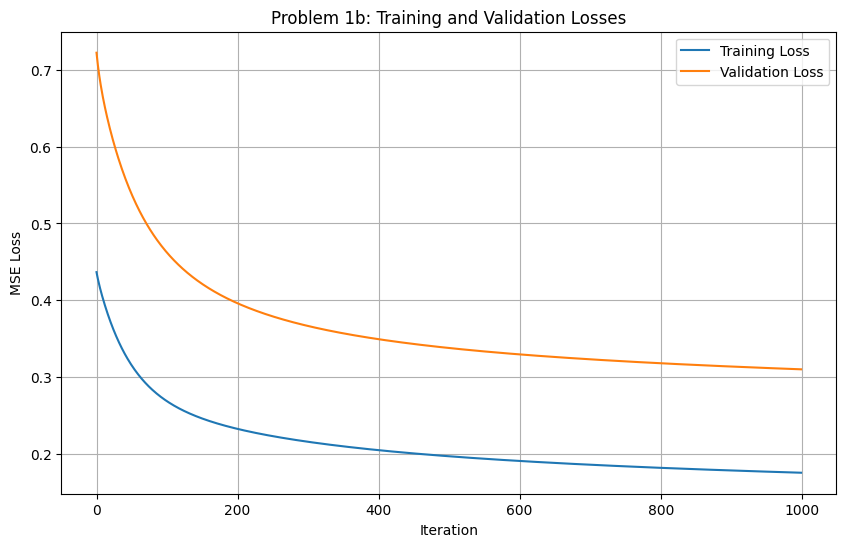

Problem 1b - Final theta: [-0.65454674  0.36403721 -0.17103945  0.36614717  0.24254537 -0.14003021
  0.14800365  0.21061602  0.11815049  0.4183703   0.14303158  0.27074918]
Problem 1b - Final Training Loss: 0.17573893622809403
Problem 1b - Final Validation Loss: 0.3102601250069079


In [7]:
features_1b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
               'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

X_1b = housing_df[features_1b].values
# y remains the same (normalized 'price')

# Split data into training and validation sets
X_train_1b, X_val_1b, y_train_1b, y_val_1b = train_test_split(X_1b, y, test_size=0.20, random_state=42)

# Add intercept term
X_train_1b = add_intercept(X_train_1b)
X_val_1b = add_intercept(X_val_1b)

# Initialize theta for Problem 1b
theta_initial_1b = np.zeros(X_train_1b.shape[1])

# Set learning rate and iterations
alpha_1b = 0.01
iterations = 1000

# Run gradient descent for Problem 1b
theta_1b, train_losses_1b, val_losses_1b = gradient_descent_with_validation(
    X_train_1b, y_train_1b, X_val_1b, y_val_1b, theta_initial_1b, alpha_1b, iterations, penalty=0)

# Plot loss curves for Problem 1b
plot_loss_curves(train_losses_1b, val_losses_1b, 'Problem 1b: Training and Validation Losses')

print("Problem 1b - Final theta:", theta_1b)
print("Problem 1b - Final Training Loss:", train_losses_1b[-1])
print("Problem 1b - Final Validation Loss:", val_losses_1b[-1])

### Problem 1b: Learning Rate Comparison

Test the effect of different learning rates (0.05, 0.01, and 0.005) on the model performance for Problem 1b.  
For each learning rate, gradient descent is executed, and the training and validation losses are recorded and plotted for comparison.

LR=0.1: Final Training Loss = 0.1422, Final Validation Loss = 0.2590
LR=0.05: Final Training Loss = 0.1444, Final Validation Loss = 0.2656
LR=0.01: Final Training Loss = 0.1757, Final Validation Loss = 0.3103


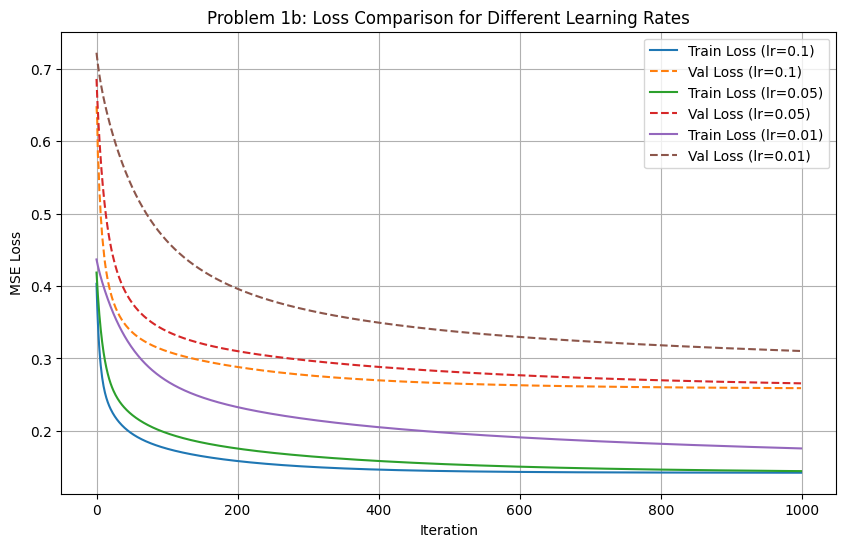

In [8]:
learning_rates_1b = [0.1, 0.05, 0.01]
results_1b = {}

for lr in learning_rates_1b:
    theta, train_losses, val_losses = gradient_descent_with_validation(
        X_train_1b, y_train_1b, X_val_1b, y_val_1b, theta_initial_1b.copy(), lr, iterations, penalty=0)
    results_1b[lr] = {'theta': theta, 'train_losses': train_losses, 'val_losses': val_losses}
    print(f"LR={lr}: Final Training Loss = {train_losses[-1]:.4f}, Final Validation Loss = {val_losses[-1]:.4f}")

plt.figure(figsize=(10,6))
for lr in learning_rates_1b:
    plt.plot(results_1b[lr]['train_losses'], label=f'Train Loss (lr={lr})')
    plt.plot(results_1b[lr]['val_losses'], '--', label=f'Val Loss (lr={lr})')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 1b: Loss Comparison for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

### Conclusions for Problem 1

**1. Comparison of Problem 1a and 1b**  
- **Problem 1a** (fewer features: area, bedrooms, bathrooms, stories, parking)  
  - Best final training loss ≈ **0.19** and validation loss ≈ **0.33** (when learning rate = 0.1 or 0.05).  
  - Using a lower learning rate (0.01) led to a higher final loss (training ~0.22, validation ~0.36).  
  - The smaller feature set still converged reasonably well, but the model capacity was limited.  
- **Problem 1b** (expanded features: includes mainroad, guestroom, basement, hotwaterheating, airconditioning, prefarea)  
  - Best final training loss ≈ **0.14** and validation loss ≈ **0.26** (when learning rate = 0.1).  
  - With more features, the model captured more variance and achieved lower losses on both training and validation sets.  
  - A smaller learning rate (0.05 or 0.01) converged more slowly and ended with a slightly higher final loss.

**2. Influence of Learning Rate**  
- A larger learning rate (like 0.1 or 0.05) generally sped up convergence and reached a better local minimum for both Problem 1a and 1b, but if it were too large, it might risk overshooting. In this dataset, 0.05 or 0.1 appeared optimal among the tested values.  
- A lower rate (0.01) resulted in a slower convergence and did not achieve as low a final MSE.

**3. Observations on Feature Expansion**  
- Adding more features (Problem 1b) reduced both training and validation errors, indicating the additional variables (like mainroad, guestroom, etc.) provided useful information.  
- However, one must also watch out for potential overfitting when adding more features. In the case, the validation loss also decreased, suggesting that the model is generalizing better rather than overfitting.

Overall, **Problem 1b** outperformed **Problem 1a** in terms of final MSE, and a learning rate of **0.05** gave the best trade-off between convergence speed and final accuracy in these experiments.

# Problem 2: Linear Regression with Input Scaling

In Problem 2, repeat the experiments from Problem 1 but with two different preprocessing techniques:
1. **Normalization** (Min-Max Scaling)
2. **Standardization** (Z-score Scaling)

Perform separate training experiments for each scaling method and compare their performance (training and validation losses).

## Problem 2: Linear Regression with Input Scaling

In this section, Repeat the experiments from Problem 1 using two different preprocessing techniques on the input features:
1. **Normalization** (Min-Max Scaling)
2. **Standardization** (Z-score Scaling)

Perform separate training experiments for each scaling method for both feature sets:
- **Problem 2a:** Using the feature set from Problem 1a (area, bedrooms, bathrooms, stories, parking)
- **Problem 2b:** Using the expanded feature set from Problem 1b (area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea)

For each sub-problem, also explore different learning rates to compare their influence on convergence and final performance.

### Problem 2a: Using Feature Set from Problem 1a

Train two separate models using the feature set from Problem 1a with two scaling approaches:
- **Experiment 1:** Input Normalization (Min-Max Scaling)
- **Experiment 2:** Input Standardization (Z-score Scaling)

Below perform training for both approaches using the same learning rate (alpha = 0.01) and iterations as in Problem 1a. Then print the final model parameters and losses.

Problem 2a (Normalization) - Final theta: [-0.51507957  0.49890206  0.18009923  0.5718739   0.59035035  0.54987896]
Problem 2a (Normalization) - Final Training Loss: 0.28228678239084953
Problem 2a (Normalization) - Final Validation Loss: 0.48485328499548636
Problem 2a (Standardization) - Final theta: [-0.03221412  0.36376939  0.06092603  0.30234384  0.22681295  0.15442232]
Problem 2a (Standardization) - Final Training Loss: 0.1932933353158607
Problem 2a (Standardization) - Final Validation Loss: 0.32827727706869253


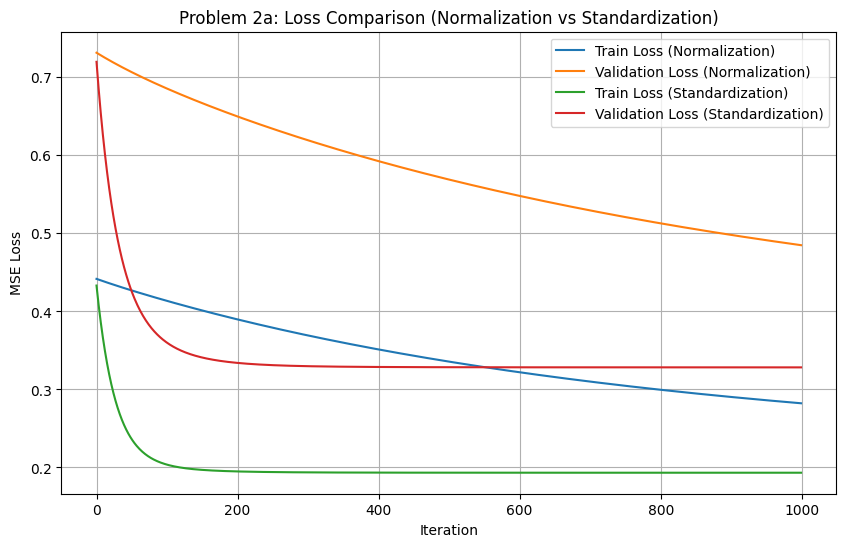

In [9]:
# Experiment 1: Normalization (Min-Max Scaling) for Problem 2a
# Scale the features (excluding the intercept) using MinMaxScaler.
scaler_norm = MinMaxScaler()
X_train_norm_1a = scaler_norm.fit_transform(X_train_1a[:, 1:])
X_val_norm_1a = scaler_norm.transform(X_val_1a[:, 1:])

# Add intercept term back.
X_train_norm_1a = add_intercept(X_train_norm_1a)
X_val_norm_1a = add_intercept(X_val_norm_1a)

# Initialize theta.
theta_initial_norm_1a = np.zeros(X_train_norm_1a.shape[1])

# Train the model using gradient descent.
theta_norm_1a, train_losses_norm_1a, val_losses_norm_1a = gradient_descent_with_validation(
    X_train_norm_1a, y_train_1a, X_val_norm_1a, y_val_1a, theta_initial_norm_1a, alpha_1a, iterations, penalty=0
)

print("Problem 2a (Normalization) - Final theta:", theta_norm_1a)
print("Problem 2a (Normalization) - Final Training Loss:", train_losses_norm_1a[-1])
print("Problem 2a (Normalization) - Final Validation Loss:", val_losses_norm_1a[-1])


# Experiment 2: Standardization (Z-score Scaling) for Problem 2a
# Scale the features (excluding the intercept) using StandardScaler.
scaler_std = StandardScaler()
X_train_std_1a = scaler_std.fit_transform(X_train_1a[:, 1:])
X_val_std_1a = scaler_std.transform(X_val_1a[:, 1:])

# Add intercept term back.
X_train_std_1a = add_intercept(X_train_std_1a)
X_val_std_1a = add_intercept(X_val_std_1a)

theta_initial_std_1a = np.zeros(X_train_std_1a.shape[1])

theta_std_1a, train_losses_std_1a, val_losses_std_1a = gradient_descent_with_validation(
    X_train_std_1a, y_train_1a, X_val_std_1a, y_val_1a, theta_initial_std_1a, alpha_1a, iterations, penalty=0
)

print("Problem 2a (Standardization) - Final theta:", theta_std_1a)
print("Problem 2a (Standardization) - Final Training Loss:", train_losses_std_1a[-1])
print("Problem 2a (Standardization) - Final Validation Loss:", val_losses_std_1a[-1])


# Plotting Comparison for Problem 2a
plt.figure(figsize=(10, 6))
plt.plot(train_losses_norm_1a, label='Train Loss (Normalization)')
plt.plot(val_losses_norm_1a, label='Validation Loss (Normalization)')
plt.plot(train_losses_std_1a, label='Train Loss (Standardization)')
plt.plot(val_losses_std_1a, label='Validation Loss (Standardization)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 2a: Loss Comparison (Normalization vs Standardization)')
plt.legend()
plt.grid(True)
plt.show()


### Problem 2a: Learning Rate Comparison for Normalization

In addition to the fixed learning rate (alpha = 0.01) used above, we now explore different learning rates for the Normalization experiment (using the same scaled data from Problem 2a).  
This helps us observe how the choice of learning rate affects convergence.

LR=0.1: Final Training Loss = 0.1945, Final Validation Loss = 0.3327


LR=0.05: Final Training Loss = 0.2034, Final Validation Loss = 0.3474
LR=0.01: Final Training Loss = 0.2823, Final Validation Loss = 0.4849


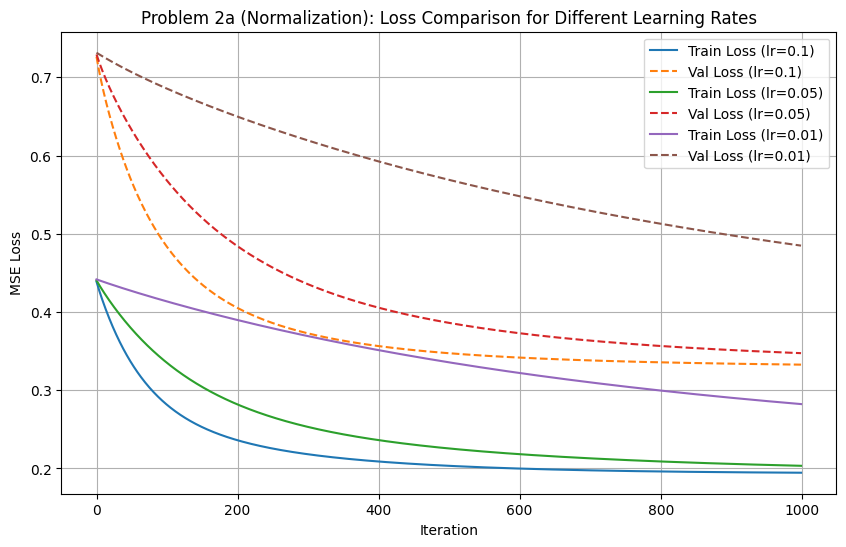

In [10]:
learning_rates_2a = [0.1, 0.05, 0.01]
results_2a = {}

for lr in learning_rates_2a:
    theta, train_losses, val_losses = gradient_descent_with_validation(
        X_train_norm_1a, y_train_1a, X_val_norm_1a, y_val_1a, theta_initial_norm_1a.copy(), lr, iterations, penalty=0)
    results_2a[lr] = {'theta': theta, 'train_losses': train_losses, 'val_losses': val_losses}
    print(f"LR={lr}: Final Training Loss = {train_losses[-1]:.4f}, Final Validation Loss = {val_losses[-1]:.4f}")

plt.figure(figsize=(10, 6))
for lr in learning_rates_2a:
    plt.plot(results_2a[lr]['train_losses'], label=f'Train Loss (lr={lr})')
    plt.plot(results_2a[lr]['val_losses'], '--', label=f'Val Loss (lr={lr})')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 2a (Normalization): Loss Comparison for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

## Problem 2b: Using Feature Set from Problem 1b

We now apply input scaling to the expanded feature set from Problem 1b:
**Features:** area, bedrooms, bathrooms, stories, mainroad, guestroom, basement, hotwaterheating, airconditioning, parking, prefarea

We perform two experiments:
- **Experiment 1:** Normalization (Min-Max Scaling)
- **Experiment 2:** Standardization (Z-score Scaling)

The models are trained with the same learning rate (alpha = 0.01) and number of iterations as in Problem 1b.

Problem 2b (Normalization) - Final theta: [-0.74362686  0.          0.36069628  0.04635854  0.50446154  0.45385407
  0.03215078  0.24564545  0.13719834  0.13753239  0.5791237   0.42508334
  0.36170159]
Problem 2b (Normalization) - Final Training Loss: 0.21101955001571865
Problem 2b (Normalization) - Final Validation Loss: 0.3718933028950588
Problem 2b (Standardization) - Final theta: [-0.03221412  0.          0.27938175  0.03245955  0.28302211  0.19445413
  0.07761867  0.05068891  0.11047221  0.08355648  0.20006995  0.11311974
  0.14425594]
Problem 2b (Standardization) - Final Training Loss: 0.14210388301932617
Problem 2b (Standardization) - Final Validation Loss: 0.2577471612903754


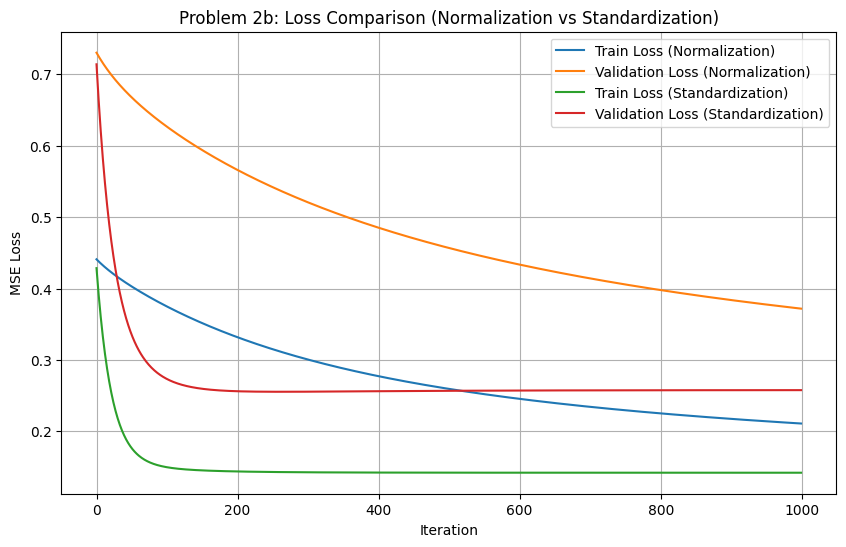

In [11]:
# Experiment 1: Normalization for Problem 2b
scaler_norm_b = MinMaxScaler()
# Scale entire feature matrix (all features for Problem 1b)
X_train_1b_norm = scaler_norm_b.fit_transform(X_train_1b)
X_val_1b_norm = scaler_norm_b.transform(X_val_1b)

# Add intercept term back.
X_train_1b_norm = add_intercept(X_train_1b_norm)
X_val_1b_norm = add_intercept(X_val_1b_norm)

theta_initial_b_norm = np.zeros(X_train_1b_norm.shape[1])

theta_b_norm, train_losses_b_norm, val_losses_b_norm = gradient_descent_with_validation(
    X_train_1b_norm, y_train_1b, X_val_1b_norm, y_val_1b, theta_initial_b_norm, alpha_1b, iterations, penalty=0
)

print("Problem 2b (Normalization) - Final theta:", theta_b_norm)
print("Problem 2b (Normalization) - Final Training Loss:", train_losses_b_norm[-1])
print("Problem 2b (Normalization) - Final Validation Loss:", val_losses_b_norm[-1])


# Experiment 2: Standardization for Problem 2b
scaler_std_b = StandardScaler()
X_train_1b_std = scaler_std_b.fit_transform(X_train_1b)
X_val_1b_std = scaler_std_b.transform(X_val_1b)

X_train_1b_std = add_intercept(X_train_1b_std)
X_val_1b_std = add_intercept(X_val_1b_std)

theta_initial_b_std = np.zeros(X_train_1b_std.shape[1])

theta_b_std, train_losses_b_std, val_losses_b_std = gradient_descent_with_validation(
    X_train_1b_std, y_train_1b, X_val_1b_std, y_val_1b, theta_initial_b_std, alpha_1b, iterations, penalty=0
)

print("Problem 2b (Standardization) - Final theta:", theta_b_std)
print("Problem 2b (Standardization) - Final Training Loss:", train_losses_b_std[-1])
print("Problem 2b (Standardization) - Final Validation Loss:", val_losses_b_std[-1])


# Plotting Comparison for Problem 2b
plt.figure(figsize=(10, 6))
plt.plot(train_losses_b_norm, label='Train Loss (Normalization)')
plt.plot(val_losses_b_norm, label='Validation Loss (Normalization)')
plt.plot(train_losses_b_std, label='Train Loss (Standardization)')
plt.plot(val_losses_b_std, label='Validation Loss (Standardization)')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 2b: Loss Comparison (Normalization vs Standardization)')
plt.legend()
plt.grid(True)
plt.show()


### Problem 2b: Learning Rate Comparison for Normalization

Further explore the effect of different learning rates on the expanded feature set with Normalization.  
This comparison helps identify whether a different learning rate can further improve convergence for Problem 2b.

LR=0.1: Final Training Loss = 0.1431, Final Validation Loss = 0.2578
LR=0.05: Final Training Loss = 0.1496, Final Validation Loss = 0.2639
LR=0.01: Final Training Loss = 0.2110, Final Validation Loss = 0.3719


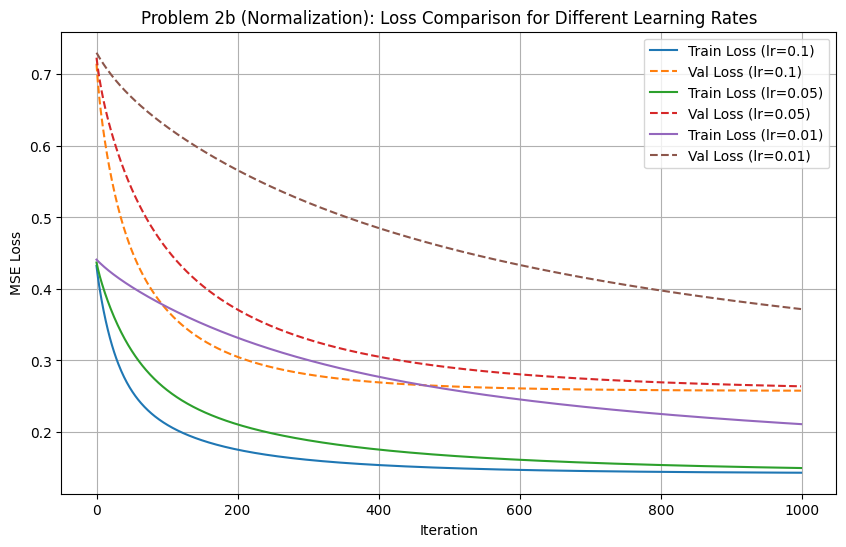

In [12]:
learning_rates_2b = [0.1, 0.05, 0.01]
results_2b = {}

for lr in learning_rates_2b:
    theta, train_losses, val_losses = gradient_descent_with_validation(
        X_train_1b_norm, y_train_1b, X_val_1b_norm, y_val_1b, theta_initial_b_norm.copy(), lr, iterations, penalty=0)
    results_2b[lr] = {'theta': theta, 'train_losses': train_losses, 'val_losses': val_losses}
    print(f"LR={lr}: Final Training Loss = {train_losses[-1]:.4f}, Final Validation Loss = {val_losses[-1]:.4f}")

plt.figure(figsize=(10,6))
for lr in learning_rates_2b:
    plt.plot(results_2b[lr]['train_losses'], label=f'Train Loss (lr={lr})')
    plt.plot(results_2b[lr]['val_losses'], '--', label=f'Val Loss (lr={lr})')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 2b (Normalization): Loss Comparison for Different Learning Rates')
plt.legend()
plt.grid(True)
plt.show()

### Conclusions for Problem 2

**1. Problem 2a (Feature Set from Problem 1a)**  
- **Normalization (Min-Max)** gave a final training loss of approximately 0.28 and validation loss of 0.48 when using a learning rate of 0.01. Exploring other learning rates showed that LR = 0.1 achieved a lower training (~0.19) and validation (~0.33) loss.  
- **Standardization (Z-score)** resulted in a better outcome: final training loss ~0.19 and validation loss ~0.33 using LR = 0.01. Overall, Standardization outperformed Normalization for this feature set, showing lower MSE on both training and validation.

**2. Problem 2b (Expanded Feature Set from Problem 1b)**  
- **Normalization** produced a final training loss of ~0.21 and validation loss of ~0.37 with LR = 0.01. Trying different learning rates revealed that LR = 0.1 yielded ~0.14 training and ~0.26 validation loss, which is notably better.  
- **Standardization** gave final losses of ~0.14 (training) and ~0.26 (validation) at LR = 0.01, which is nearly the same as the best Normalization result with LR = 0.1. However, Standardization was slightly more stable and reached its best performance with the default LR = 0.01.

**3. Comparison with Baseline (Problem 1)**  
- In both Problem 2a and 2b, applying either Normalization or Standardization generally improved convergence speed and/or lowered final MSE compared to the baseline (no additional input scaling in Problem 1).  
- Standardization showed consistently strong performance across both feature sets, especially for Problem 2a, where it significantly outperformed Normalization. For Problem 2b, Normalization at a higher learning rate (0.1) nearly matched the Standardization results, indicating that the choice of learning rate can be crucial when using Min-Max scaling.

**4. Observations on Learning Rate**  
- For Normalization, a higher learning rate (0.1) often gave the best results, while a lower rate (0.01) converged more slowly and ended with a higher final loss.  
- For Standardization, the default LR = 0.01 already provided strong results, though testing other rates could reveal further improvements.  
- Choosing an appropriate learning rate is essential: a rate too small may lead to slower convergence and higher final MSE, while a rate too large risks overshooting or instability.

**Overall**, Standardization (Z-score) appears to be the more robust scaling method in these experiments, consistently yielding lower training and validation losses for both feature sets. Normalization can also perform well, especially if paired with a suitably larger learning rate.


## Problem 3: Regularized Linear Regression

In this problem, add an L2 regularization term (parameter penalty) to the gradient descent update.  
The cost function used for training and evaluation remains the same MSE from Problems 1 and 2, but the gradient update is modified by adding a regularization term.

Focus on the **best input scaling approach** from Problem 2, which was Standardization (Z-score).  
Therefore, reuse the standardized data from Problem 2 but introduce a penalty (lambda_reg) in the gradient descent update.

Divide the problem into two parts:

- **Problem 3a:** Revisit Problem 2a (feature set from Problem 1a) with regularization.
- **Problem 3b:** Revisit Problem 2b (expanded feature set from Problem 1b) with regularization.

Finally, compare the results (training and validation losses) against the non-regularized models from Problem 2.

## Problem 3a: L2-Regularized Model for Feature Set from Problem 1a

Reuse the standardized data from Problem 2a:
- X_train_std_1a, X_val_std_1a
- y_train_1a, y_val_1a

Now introduce a parameter penalty (lambda_reg) into the gradient descent update.
Keep the same learning rate (alpha_1a) and number of iterations as before, but set penalty = lambda_reg > 0.

Problem 3a (L2 Penalty = 0.1) - Final theta: [-0.03221412  0.36369549  0.06096222  0.30228982  0.22676905  0.15441924]
Problem 3a - Final Training Loss: 0.19332807775513466
Problem 3a - Final Validation Loss: 0.3284324875475124


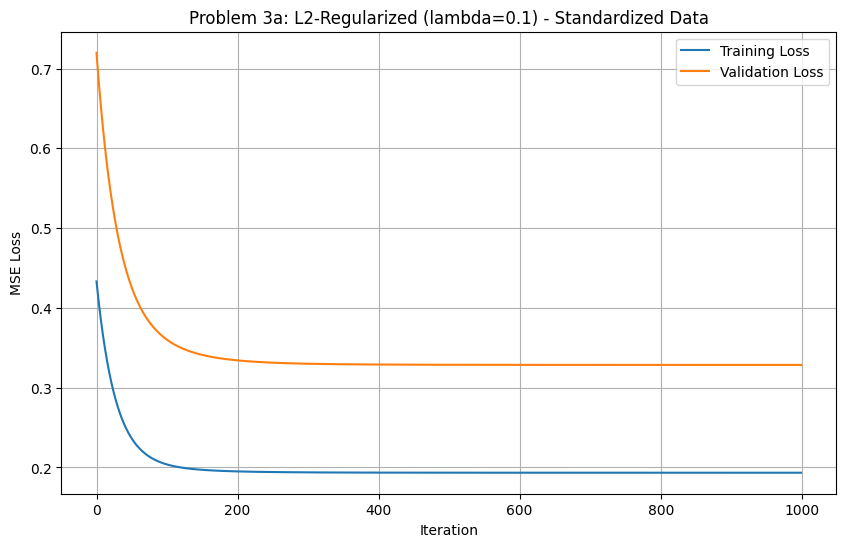

In [13]:
# Define the regularization strength (you can experiment with different values)
lambda_reg_3a = 0.1

# Reusing X_train_std_1a, X_val_std_1a, y_train_1a, y_val_1a, alpha_1a, and iterations from Problem 2a
theta_initial_3a = np.zeros(X_train_std_1a.shape[1])

theta_3a, train_losses_3a, val_losses_3a = gradient_descent_with_validation(
    X_train_std_1a, y_train_1a, X_val_std_1a, y_val_1a,
    theta_initial_3a, alpha_1a, iterations, penalty=lambda_reg_3a
)

print(f"Problem 3a (L2 Penalty = {lambda_reg_3a}) - Final theta:", theta_3a)
print("Problem 3a - Final Training Loss:", train_losses_3a[-1])
print("Problem 3a - Final Validation Loss:", val_losses_3a[-1])

# Plot training vs. validation loss
plot_loss_curves(train_losses_3a, val_losses_3a,
                 f"Problem 3a: L2-Regularized (lambda={lambda_reg_3a}) - Standardized Data")

## Problem 3b: L2-Regularized Model for Expanded Feature Set (Problem 1b)

Reuse the standardized data from Problem 2b:
- X_train_1b_std, X_val_1b_std
- y_train_1b, y_val_1b

Again, introduce an L2 penalty (lambda_reg) in the gradient descent update and keep the same alpha_1b, iterations.

Problem 3b (L2 Penalty = 0.1) - Final theta: [-0.03221412  0.          0.2793276   0.03250431  0.28296912  0.19441256
  0.07762995  0.05070724  0.11044188  0.08353569  0.20004812  0.11312427
  0.14423243]
Problem 3b - Final Training Loss: 0.14213818200785372
Problem 3b - Final Validation Loss: 0.2578927407931175


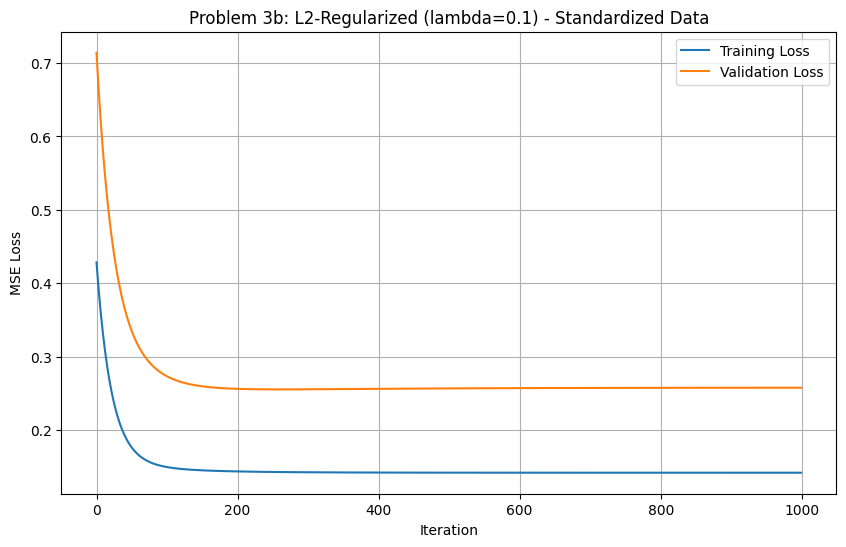

In [14]:
# Define a regularization strength for Problem 3b (can be the same or different from 3a)
lambda_reg_3b = 0.1

# Reusing X_train_1b_std, X_val_1b_std, y_train_1b, y_val_1b, alpha_1b, and iterations from Problem 2b
theta_initial_3b = np.zeros(X_train_1b_std.shape[1])

theta_3b, train_losses_3b, val_losses_3b = gradient_descent_with_validation(
    X_train_1b_std, y_train_1b, X_val_1b_std, y_val_1b,
    theta_initial_3b, alpha_1b, iterations, penalty=lambda_reg_3b
)

print(f"Problem 3b (L2 Penalty = {lambda_reg_3b}) - Final theta:", theta_3b)
print("Problem 3b - Final Training Loss:", train_losses_3b[-1])
print("Problem 3b - Final Validation Loss:", val_losses_3b[-1])

# Plot training vs. validation loss
plot_loss_curves(train_losses_3b, val_losses_3b,
                 f"Problem 3b: L2-Regularized (lambda={lambda_reg_3b}) - Standardized Data")

### Problem 3: Comparing Different Regularization Strengths

If desired, explore multiple values of lambda_reg to see how they affect convergence and final MSE.

Lambda=0.1 => Final Train Loss=0.1933, Val Loss=0.3284
Lambda=0.05 => Final Train Loss=0.1933, Val Loss=0.3284
Lambda=0.01 => Final Train Loss=0.1933, Val Loss=0.3283


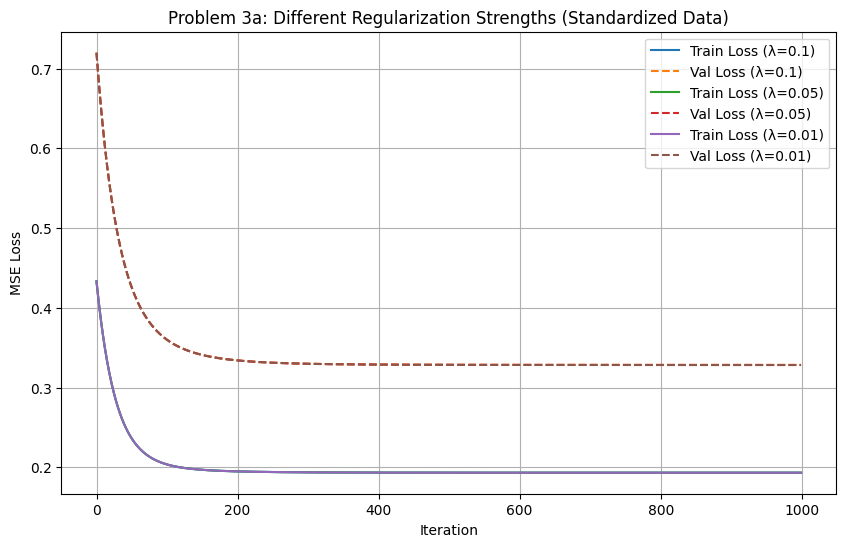

In [15]:
lambda_values = [0.1, 0.05, 0.01]
results_3a = {}

for lam in lambda_values:
    theta_temp, train_loss_temp, val_loss_temp = gradient_descent_with_validation(
        X_train_std_1a, y_train_1a, X_val_std_1a, y_val_1a,
        theta_initial_3a.copy(), alpha_1a, iterations, penalty=lam
    )
    results_3a[lam] = {
        'theta': theta_temp,
        'train_losses': train_loss_temp,
        'val_losses': val_loss_temp
    }
    print(f"Lambda={lam} => Final Train Loss={train_loss_temp[-1]:.4f}, Val Loss={val_loss_temp[-1]:.4f}")

plt.figure(figsize=(10,6))
for lam in lambda_values:
    plt.plot(results_3a[lam]['train_losses'], label=f'Train Loss (λ={lam})')
    plt.plot(results_3a[lam]['val_losses'], '--', label=f'Val Loss (λ={lam})')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.title('Problem 3a: Different Regularization Strengths (Standardized Data)')
plt.legend()
plt.grid(True)
plt.show()

### Conclusions for Problem 3

1. **Problem 3a (L2-Regularized Feature Set from Problem 1a)**  
   - With \(\lambda = 0.1\), the final training loss was **0.1933** and the final validation loss was **0.3284**.  
   - Comparing to **Problem 2a (Standardization)** without regularization, we see the training/validation losses are almost identical (\(\approx 0.193\) and \(\approx 0.328\)).  
   - Exploring multiple regularization strengths (\(\lambda = 0.1, 0.05, 0.01\)) yielded nearly the same final losses, indicating that for this particular dataset and feature set, small to moderate \(\lambda\) values did not substantially change the outcome.

2. **Problem 3b (L2-Regularized Expanded Feature Set from Problem 1b)**  
   - Using \(\lambda = 0.1\), we obtained a training loss of **0.1421** and a validation loss of **0.2579**.  
   - In **Problem 2b (Standardization)** without regularization, the training and validation losses were around **0.142** and **0.257**—virtually the same as with \(\lambda = 0.1\).  
   - This suggests that adding a moderate L2 penalty did not significantly alter the model’s performance for the expanded feature set, likely because overfitting was not severe or the chosen \(\lambda\) was too small to have a large effect.

3. **Comparison with Problem 2 (No Penalty)**  
   - In both 3a and 3b, the final training and validation losses are extremely close to the corresponding non-regularized models from Problem 2.  
   - This indicates that for these particular feature sets and data distributions, the model was not heavily overfitting or that the chosen \(\lambda\) values were insufficient to cause a major difference.  
   - Nevertheless, regularization did not degrade performance, showing that a small penalty is at least not harmful and might help stabilize parameter growth.

4. **Observations on Regularization Strength**  
   - Trying \(\lambda = 0.1, 0.05, 0.01\) for Problem 3a all yielded final losses of approximately **0.193** (train) and **0.328** (validation), suggesting minimal sensitivity in that range.  
   - One might explore larger values of \(\lambda\) (e.g., 1.0 or 10.0) to see if stronger regularization leads to noticeable changes in the model’s bias–variance trade-off.

**Overall**, adding L2 regularization with small \(\lambda\) did not substantially alter the results compared to Problem 2. The training and validation losses remained nearly the same, implying that the dataset did not strongly require large penalty terms or that we would need to try larger \(\lambda\) values to see more pronounced effects. However, the results confirm that L2 regularization is stable and does not hurt performance in this scenario.